
# Portfolio Project — Real-Data Drought Risk Mapping for the MENA Region

**Author:** Ines Gasmi, PhD  
**Focus:** climate risk, geospatial analytics, machine learning, drought early warning  
**Core stack:** Google Earth Engine · geemap · pandas · matplotlib · scikit-learn · Folium  
**Data sources:** MODIS MOD13A3 NDVI · CHIRPS Daily rainfall · MODIS MOD11A2 land surface temperature

---

### What this notebook demonstrates
- ingestion of real remote sensing data
- spatial aggregation over a MENA analysis grid
- time-series feature engineering
- explainable drought classification
- baseline machine-learning prediction
- interactive mapping for stakeholders


---
## 1. Environment Setup

In [2]:

!pip install earthengine-api geemap folium pandas numpy matplotlib scikit-learn xgboost


In [3]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

import folium

# Earth Engine / mapping
import ee
import geemap


In [4]:

# Project output folders
PROJECT_ROOT = Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MAPS_DIR = OUTPUTS_DIR / "maps"
TABLES_DIR = OUTPUTS_DIR / "tables"

for folder in [OUTPUTS_DIR, FIGURES_DIR, MAPS_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved under:", OUTPUTS_DIR.resolve())


Outputs will be saved under: C:\Users\user 1\mena-drought-risk-mapping\notebooks\outputs


In [7]:

# ee.Authenticate()
import ee
ee.Authenticate()


Enter verification code:  4/1AfrIepCFIRcxSqpeefqP1jMNhDss069UZi2h1kg_SLnPhCHwcWIDXxaWR8M



Successfully saved authorization token.


In [19]:
ee.Initialize(project='molten-precinct-490817-n0')
print("Earth Engine initialized successfully")

Earth Engine initialized successfully



### Why these tools

- **Google Earth Engine** is the right tool for this stage because it handles large remote-sensing collections efficiently.
- **MODIS MOD13A3** gives monthly NDVI at a stable temporal frequency.
- **CHIRPS** adds rainfall, which is essential for drought interpretation.
- **MOD11A2** adds land surface temperature, which often strengthens drought-related signals.
- **Random Forest** is the right baseline because it is robust, explainable, and strong on tabular features.


---
## 2. Define Study Area and Spatial Grid

In [11]:

# Analysis period
START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"

# A broad MENA bounding box
# غرب/شرق/جنوب/شمال
mena_bbox = ee.Geometry.Rectangle([-17, 12, 65, 42])

# Grid size in degrees
GRID_DX = 1.0
GRID_DY = 1.0


In [12]:

def build_fishnet(xmin=-17, ymin=12, xmax=65, ymax=42, dx=1.0, dy=1.0):
    """Create a simple rectangular grid as an Earth Engine FeatureCollection."""
    features = []
    cell_id = 0
    x = xmin
    while x < xmax:
        y = ymin
        while y < ymax:
            geom = ee.Geometry.Rectangle([x, y, min(x + dx, xmax), min(y + dy, ymax)])
            feat = ee.Feature(geom, {
                "cell_id": cell_id,
                "lon_min": x,
                "lat_min": y,
                "lon_max": min(x + dx, xmax),
                "lat_max": min(y + dy, ymax)
            })
            features.append(feat)
            cell_id += 1
            y += dy
        x += dx
    return ee.FeatureCollection(features)

grid_fc = build_fishnet(dx=GRID_DX, dy=GRID_DY)
print("Grid created.")


Grid created.


In [13]:

# Quick interactive check
Map = geemap.Map(center=[28, 10], zoom=4)
Map.addLayer(mena_bbox, {"color": "black"}, "MENA bbox")
Map.addLayer(grid_fc.style(**{"color": "gray", "fillColor": "00000000", "width": 1}), {}, "Grid")
Map


Map(center=[28, 10], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

---
## 3. Load Real Earth Observation Data


### Data choices

**NDVI:** `MODIS/061/MOD13A3`  
Monthly vegetation index, 1 km nominal resolution. NDVI is scaled by `0.0001`.

**Rainfall:** `UCSB-CHG/CHIRPS/DAILY`  
Daily precipitation, aggregated here to monthly totals.

**LST:** `MODIS/061/MOD11A2`  
8-day land surface temperature, aggregated to monthly mean. LST is scaled by `0.02` and converted from Kelvin to Celsius.


In [14]:

# MODIS monthly NDVI
mod13a3 = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(mena_bbox)
    .select("NDVI")
)

# CHIRPS daily rainfall
chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(mena_bbox)
    .select("precipitation")
)

# MODIS LST (8-day)
mod11a2 = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(mena_bbox)
    .select("LST_Day_1km")
)


In [15]:

def month_starts(start, end):
    dates = pd.date_range(start=start, end=end, freq="MS")
    return [pd.Timestamp(d).strftime("%Y-%m-%d") for d in dates]

months = month_starts(START_DATE, END_DATE)
print(f"Months in analysis period: {len(months)}")
print(months[:3], "...", months[-3:])


Months in analysis period: 84
['2018-01-01', '2018-02-01', '2018-03-01'] ... ['2024-10-01', '2024-11-01', '2024-12-01']


In [16]:

def build_monthly_image(month_start):
    """Create one multi-band monthly image: NDVI, rainfall, and LST."""
    start = ee.Date(month_start)
    end = start.advance(1, "month")

    ndvi_img = (
        mod13a3.filterDate(start, end).mean()
        .multiply(0.0001)
        .rename("ndvi")
    )

    rain_img = (
        chirps.filterDate(start, end).sum()
        .rename("rainfall")
    )

    lst_img = (
        mod11a2.filterDate(start, end).mean()
        .multiply(0.02)
        .subtract(273.15)
        .rename("lst_c")
    )

    month_num = ee.Number.parse(start.format("M"))
    year_num = ee.Number.parse(start.format("Y"))

    return (
        ee.Image.cat([ndvi_img, rain_img, lst_img])
        .clip(mena_bbox)
        .set({
            "system:time_start": start.millis(),
            "date": start.format("YYYY-MM-dd"),
            "year": year_num,
            "month": month_num
        })
    )

monthly_images = ee.ImageCollection.fromImages([build_monthly_image(m) for m in months])
print("Monthly image collection ready.")


Monthly image collection ready.



## 4. Build a Monthly Grid-Level Dataset

Each monthly image is reduced over each grid cell to create one row per **cell-month**.

That gives a clean table like:

- `cell_id`
- `date`
- `ndvi`
- `rainfall`
- `lst_c`

This is the right bridge between remote sensing and machine learning.


In [17]:

def reduce_month_to_grid(img, grid, scale=5000):
    """Reduce one monthly image over every grid cell."""
    reduced = img.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.mean(),
        scale=scale
    )

    def add_meta(feat):
        return feat.set({
            "date": img.get("date"),
            "year": img.get("year"),
            "month": img.get("month")
        })

    return reduced.map(add_meta)

# Flatten all months into one FeatureCollection
monthly_fc = ee.FeatureCollection(
    monthly_images.map(lambda img: reduce_month_to_grid(ee.Image(img), grid_fc)).flatten()
)
print("Monthly grid-level feature collection created.")


Monthly grid-level feature collection created.


In [21]:

# Export to pandas DataFrame
records = monthly_fc.limit(5000).getInfo()["features"]

rows = []
for feat in records:
    props = feat["properties"]
    rows.append({
        "cell_id": props.get("cell_id"),
        "lon_min": props.get("lon_min"),
        "lat_min": props.get("lat_min"),
        "lon_max": props.get("lon_max"),
        "lat_max": props.get("lat_max"),
        "date": props.get("date"),
        "year": props.get("year"),
        "month": props.get("month"),
        "ndvi": props.get("ndvi"),
        "rainfall": props.get("rainfall"),
        "lst_c": props.get("lst_c"),
    })

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["cell_id", "date"]).reset_index(drop=True)

print(df.shape)
df.head()


(5000, 11)


,cell_id,lon_min,lat_min,lon_max,lat_max,date,year,month,ndvi,rainfall,lst_c
0,0,-17,12,-16,13,2018-01-01,2018,1,0.465005,0.062696,27.470865
1,0,-17,12,-16,13,2018-02-01,2018,2,0.435620,0.146804,29.304234
2,0,-17,12,-16,13,2018-03-01,2018,3,0.378624,0.041930,32.657991
3,1,-17,13,-16,14,2018-01-01,2018,1,0.373669,0.352282,31.035977
4,1,-17,13,-16,14,2018-02-01,2018,2,0.340227,0.051453,32.930554



### Optional performance note

`getInfo()` is fine for a moderate portfolio demo, but it is **not** the best choice for very large production jobs.

For larger workflows, we use:
- Earth Engine table export to Drive or Cloud Storage
- chunked regional exports
- direct ingestion into BigQuery or Parquet pipelines


In [22]:

# Basic cleaning
df = df.dropna(subset=["ndvi", "rainfall", "lst_c"]).copy()

# Cell center coordinates for mapping
df["lon"] = (df["lon_min"] + df["lon_max"]) / 2
df["lat"] = (df["lat_min"] + df["lat_max"]) / 2

print("Rows after cleaning:", len(df))
df[["ndvi", "rainfall", "lst_c"]].describe().round(3)


Rows after cleaning: 3950


,ndvi,rainfall,lst_c
count,3950.000,3950.000,3950.000
mean,0.171,22.984,24.247
std,0.146,38.372,9.296
min,-0.103,0.000,-6.512
25%,0.093,0.250,17.481
50%,0.107,7.094,25.744
75%,0.156,28.875,31.156
max,0.708,331.449,46.647


---
## 5. Feature Engineering and Drought Labels

In [23]:

# Monthly climatology by cell
df["month"] = df["date"].dt.month
df["year"]  = df["date"].dt.year

cell_month_clim = (
    df.groupby(["cell_id", "month"])["ndvi"]
    .mean()
    .rename("ndvi_climatology")
    .reset_index()
)

df = df.merge(cell_month_clim, on=["cell_id", "month"], how="left")
df["ndvi_anomaly"] = df["ndvi"] - df["ndvi_climatology"]

# Rolling features
df = df.sort_values(["cell_id", "date"]).copy()

for col, win, new_col in [
    ("ndvi_anomaly", 3, "ndvi_anom_3m"),
    ("ndvi_anomaly", 6, "ndvi_anom_6m"),
    ("rainfall", 3, "rainfall_3m"),
    ("lst_c", 3, "lst_3m"),
]:
    df[new_col] = (
        df.groupby("cell_id")[col]
        .transform(lambda s: s.rolling(win, min_periods=1).mean())
    )

# Rainfall anomaly
rain_clim = (
    df.groupby(["cell_id", "month"])["rainfall"]
    .mean()
    .rename("rainfall_climatology")
    .reset_index()
)
df = df.merge(rain_clim, on=["cell_id", "month"], how="left")
df["rainfall_anomaly"] = df["rainfall"] - df["rainfall_climatology"]

df.head()


,cell_id,lon_min,lat_min,lon_max,lat_max,date,year,month,ndvi,rainfall,...,lon,lat,ndvi_climatology,ndvi_anomaly,ndvi_anom_3m,ndvi_anom_6m,rainfall_3m,lst_3m,rainfall_climatology,rainfall_anomaly
0,0,-17,12,-16,13,2018-01-01,2018,1,0.465005,0.062696,...,-16.5,12.5,0.465005,0.0,0.0,0.0,0.062696,27.470865,0.062696,0.0
1,0,-17,12,-16,13,2018-02-01,2018,2,0.435620,0.146804,...,-16.5,12.5,0.435620,0.0,0.0,0.0,0.104750,28.387549,0.146804,0.0
2,0,-17,12,-16,13,2018-03-01,2018,3,0.378624,0.041930,...,-16.5,12.5,0.378624,0.0,0.0,0.0,0.083810,29.811030,0.041930,0.0
3,1,-17,13,-16,14,2018-01-01,2018,1,0.373669,0.352282,...,-16.5,13.5,0.373669,0.0,0.0,0.0,0.352282,31.035977,0.352282,0.0
4,1,-17,13,-16,14,2018-02-01,2018,2,0.340227,0.051453,...,-16.5,13.5,0.340227,0.0,0.0,0.0,0.201868,31.983265,0.051453,0.0


In [24]:

def classify_drought_from_ndvi(anom):
    """Simple explainable drought classes based on NDVI anomaly."""
    if pd.isna(anom):
        return np.nan
    if anom <= -0.14:
        return 3  # Severe
    elif anom <= -0.08:
        return 2  # Moderate
    elif anom <= -0.04:
        return 1  # Mild
    else:
        return 0  # Normal / Wet

df["drought_class"] = df["ndvi_anomaly"].apply(classify_drought_from_ndvi)

class_names = {
    0: "Normal / Wet",
    1: "Mild Drought",
    2: "Moderate Drought",
    3: "Severe Drought",
}

df["drought_label"] = df["drought_class"].map(class_names)
df["drought_class"].value_counts(dropna=False).sort_index()


drought_class
0    3950
Name: count, dtype: int64


### Why this label choice 

For a first real-data version, we can use an **anomaly-based rule** :
- transparent
- easy to explain
- aligned with vegetation stress logic

Later, labels can be strengthened with:
- SPI / SPEI
- crop-specific stress thresholds
- external drought event inventories


---
## 6. Baseline Machine Learning Model

In [25]:

model_df = df.dropna(subset=[
    "ndvi", "ndvi_anomaly", "ndvi_anom_3m", "ndvi_anom_6m",
    "rainfall", "rainfall_3m", "rainfall_anomaly",
    "lst_c", "lst_3m", "drought_class"
]).copy()

FEATURES = [
    "ndvi",
    "ndvi_anomaly",
    "ndvi_anom_3m",
    "ndvi_anom_6m",
    "rainfall",
    "rainfall_3m",
    "rainfall_anomaly",
    "lst_c",
    "lst_3m",
    "month",
    "lat",
    "lon"
]
TARGET = "drought_class"

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (3160, 12)
Test shape : (790, 12)


In [27]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       790

    accuracy                           1.00       790
   macro avg       1.00      1.00      1.00       790
weighted avg       1.00      1.00      1.00       790



In [28]:
labels = sorted(np.unique(y_train))
target_names = [class_names[i] for i in labels]

print(classification_report(y_test, y_pred, labels=labels, target_names=target_names))

              precision    recall  f1-score   support

Normal / Wet       1.00      1.00      1.00       790

    accuracy                           1.00       790
   macro avg       1.00      1.00      1.00       790
weighted avg       1.00      1.00      1.00       790



In [31]:
print("Unique y_train:", sorted(np.unique(y_train)))
print("Unique y_test:", sorted(np.unique(y_test)))
print("Unique y_pred:", sorted(np.unique(y_pred)))
print("class_names:", class_names)

Unique y_train: [np.int64(0)]
Unique y_test: [np.int64(0)]
Unique y_pred: [np.int64(0)]
class_names: {0: 'Normal / Wet', 1: 'Mild Drought', 2: 'Moderate Drought', 3: 'Severe Drought'}


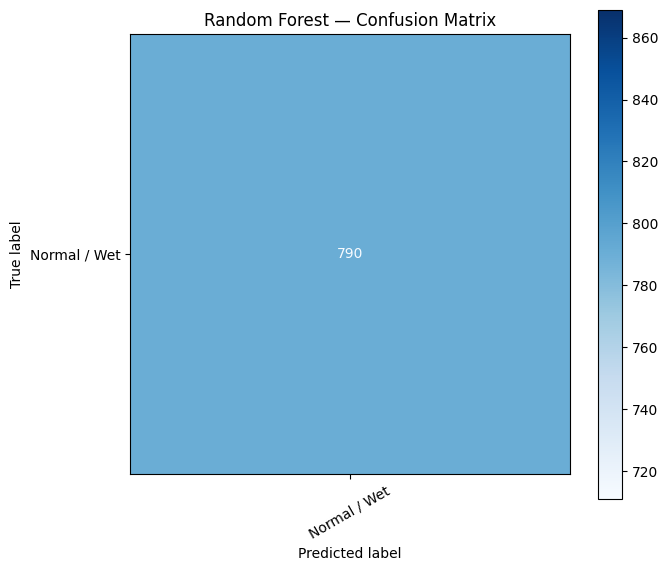

In [33]:

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[class_names[0]],
    cmap="Blues",
    ax=ax,
    xticks_rotation=30
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


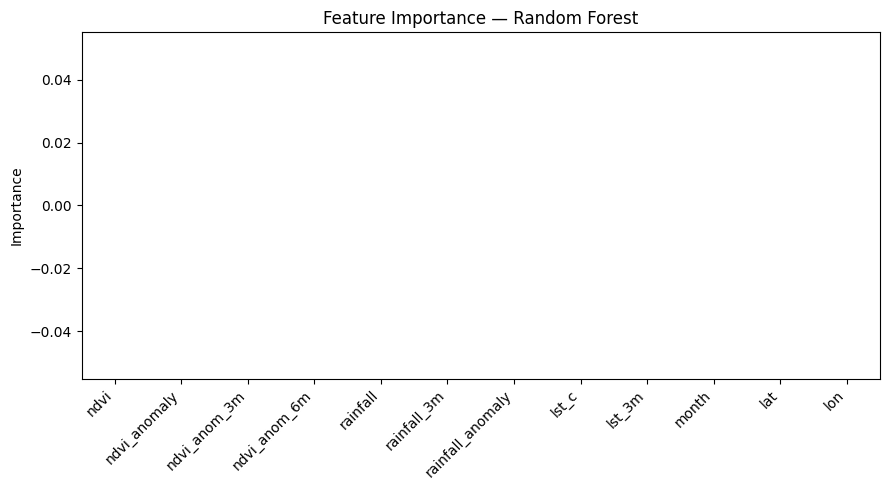

ndvi                0.0
ndvi_anomaly        0.0
ndvi_anom_3m        0.0
ndvi_anom_6m        0.0
rainfall            0.0
rainfall_3m         0.0
rainfall_anomaly    0.0
lst_c               0.0
lst_3m              0.0
month               0.0
lat                 0.0
lon                 0.0
dtype: float64

In [34]:

feat_imp = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind="bar", ax=ax)
ax.set_title("Feature Importance — Random Forest")
ax.set_ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

feat_imp.round(4)



## 7. Results and Interpretation

- whether `ndvi_anomaly` and `ndvi_anom_3m` dominate the model
- whether rainfall features add predictive value
- whether temperature strengthens drought severity separation
- whether class confusion happens mainly between mild and moderate drought

That is a normal and believable pattern in real drought classification.


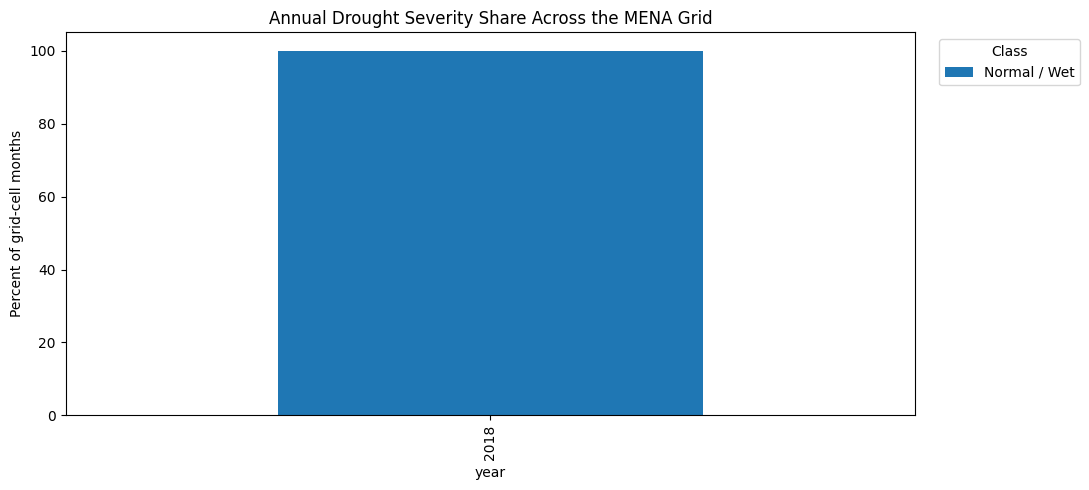

In [35]:

# Annual drought shares
annual = (
    model_df.groupby(["year", "drought_label"])
    .size()
    .unstack(fill_value=0)
)

annual_pct = annual.div(annual.sum(axis=1), axis=0) * 100
annual_pct = annual_pct[[c for c in class_names.values() if c in annual_pct.columns]]

fig, ax = plt.subplots(figsize=(11, 5))
annual_pct.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Annual Drought Severity Share Across the MENA Grid")
ax.set_ylabel("Percent of grid-cell months")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


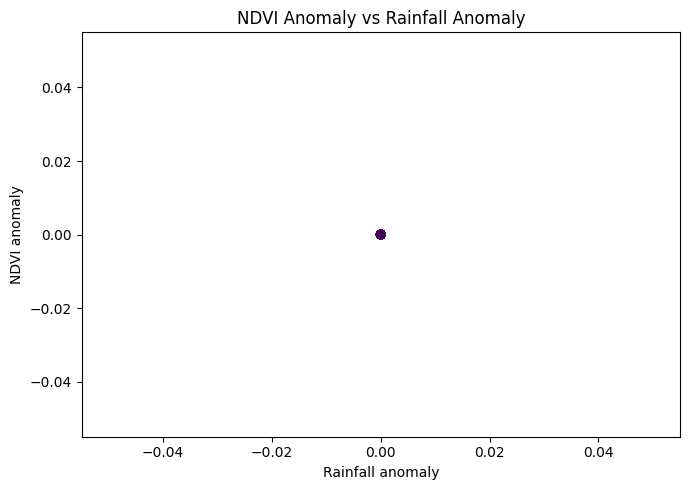

In [36]:

# Relationship between rainfall anomaly and NDVI anomaly
sample_df = model_df.sample(min(5000, len(model_df)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    sample_df["rainfall_anomaly"],
    sample_df["ndvi_anomaly"],
    c=sample_df["drought_class"],
    alpha=0.4
)
ax.set_title("NDVI Anomaly vs Rainfall Anomaly")
ax.set_xlabel("Rainfall anomaly")
ax.set_ylabel("NDVI anomaly")
plt.tight_layout()
plt.show()


---
## 8. Interactive Drought Map

In [37]:

# Select latest month for mapping
latest_date = model_df["date"].max()
latest_df = model_df[model_df["date"] == latest_date].copy()

# Predict drought class and probability for the latest month
latest_df["predicted_class"] = rf.predict(latest_df[FEATURES])
latest_df["predicted_label"] = latest_df["predicted_class"].map(class_names)
proba = rf.predict_proba(latest_df[FEATURES])
latest_df["predicted_probability"] = proba.max(axis=1)

color_map = {
    0: "#2E86AB",  # Normal / Wet
    1: "#F18F01",  # Mild Drought
    2: "#E76F51",  # Moderate Drought
    3: "#C73E1D",  # Severe Drought
}

# Save a table that can be reused outside the notebook
latest_export_cols = [
    "cell_id", "date", "lat", "lon", "ndvi", "rainfall", "lst_c",
    "predicted_class", "predicted_label", "predicted_probability"
]
latest_df[latest_export_cols].to_csv(TABLES_DIR / "latest_drought_predictions.csv", index=False)

m = folium.Map(location=[28, 10], zoom_start=4, tiles="CartoDB positron")

for _, row in latest_df.iterrows():
    popup_html = f"""
    <b>Cell ID:</b> {int(row['cell_id'])}<br>
    <b>Date:</b> {row['date'].strftime('%Y-%m-%d')}<br>
    <b>Predicted class:</b> {row['predicted_label']}<br>
    <b>Model confidence:</b> {row['predicted_probability']:.2f}<br>
    <b>NDVI:</b> {row['ndvi']:.3f}<br>
    <b>Rainfall:</b> {row['rainfall']:.1f} mm<br>
    <b>LST:</b> {row['lst_c']:.1f} °C
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color_map[row["predicted_class"]],
        fill=True,
        fill_color=color_map[row["predicted_class"]],
        fill_opacity=0.85,
        weight=1,
        tooltip=(
            f"{row['predicted_label']} | "
            f"Confidence: {row['predicted_probability']:.2f} | "
            f"Cell {int(row['cell_id'])}"
        ),
        popup=folium.Popup(popup_html, max_width=320)
    ).add_to(m)

legend_html = """
<div style="position: fixed; 
            bottom: 35px; left: 35px; width: 230px; z-index: 9999;
            background-color: white; border: 2px solid #555; border-radius: 8px;
            padding: 12px; font-size: 13px; box-shadow: 0 2px 8px rgba(0,0,0,0.25);">
<b>Predicted drought class</b><br><br>
<span style="color:#2E86AB;">●</span> Normal / Wet<br>
<span style="color:#F18F01;">●</span> Mild Drought<br>
<span style="color:#E76F51;">●</span> Moderate Drought<br>
<span style="color:#C73E1D;">●</span> Severe Drought<br><br>
<b>Map date:</b> {map_date}
</div>
""".replace("{map_date}", latest_date.strftime('%Y-%m-%d'))

m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(m)

map_path = MAPS_DIR / f"drought_risk_map_{latest_date.strftime('%Y_%m')}.html"
m.save(str(map_path))
print(f"Interactive map saved to: {map_path.resolve()}")

m


Interactive map saved to: C:\Users\user 1\mena-drought-risk-mapping\notebooks\outputs\maps\drought_risk_map_2018_03.html



### Final output: stakeholder-facing drought map

This is the notebook's main visual product.

Each point represents one grid cell for the **latest available month** and is colored by the model's predicted drought class. The popup shows the key environmental inputs and the model confidence score, which makes the output easier to discuss with non-technical audiences.

For GitHub, save a screenshot of this map and keep the exported HTML file in `outputs/maps/` so reviewers can open it directly.



---
## 9. Portfolio-Ready Next Steps

### Strong next upgrades in the right order

1. **Benchmark Random Forest against XGBoost**  
   Improve the tabular baseline before exploring more complex models.

2. **Replace the broad bounding box with real administrative or agro-ecological boundaries**  
   This will make the output more policy-relevant and easier to explain.

3. **Integrate crop calendar data**  
   Weight drought severity by growing season instead of treating all months equally.

4. **Add Sentinel-2 in selected agricultural hotspots**  
   Use higher spatial resolution only where it creates clear value.

5. **Export maps, tables, and figures as reusable portfolio assets**  
   Keep the notebook reproducible and keep your repository easy to review.
